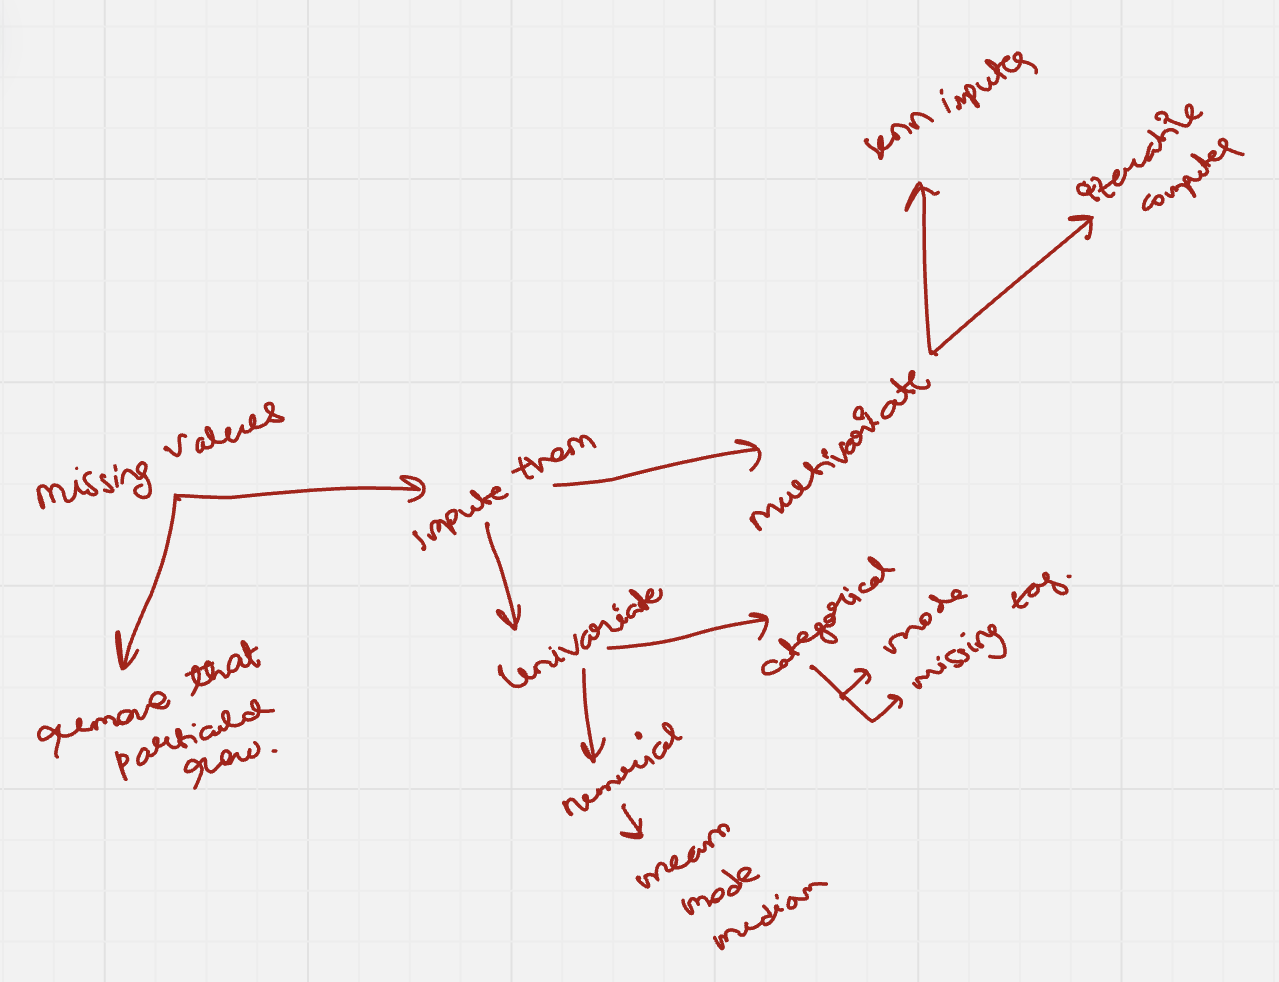

## Handling Missing Values in Numeric and Categorical Data

This section uses a randomly generated dataset and keeps the existing notebook content unchanged.

### Numeric feature possibilities
- Drop rows with missing values.
- Drop the entire column when it has too many missing values and is not important.
- Fill with mean when the feature is roughly symmetric and has no strong outliers.
- Fill with median when the feature is skewed or has outliers.
- Fill with mode when repeated numeric values are meaningful.
- Fill with a constant such as `0` or `-1` when that value has a clear interpretation.

### Categorical feature possibilities
- Drop rows with missing values when only a few rows are affected.
- Drop the column when it has too many missing values and is not important.
- Fill with mode as a simple baseline.
- Fill with a constant category such as `Unknown` or `Missing`.
- Add a missing indicator when the fact that a value is missing may itself be useful.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# Random dataset with both numeric and categorical missing values
random_df = pd.DataFrame(
    {
        "age": [23, 25, np.nan, 29, 31, np.nan, 35, 37, 41, 45],
        "salary": [32000, np.nan, 41000, 45000, np.nan, 52000, 58000, 61000, np.nan, 72000],
        "score": [75, 80, 80, np.nan, 88, 91, np.nan, 95, 95, 99],
        "city": ["Delhi", "Mumbai", None, "Chennai", "Delhi", None, "Pune", "Mumbai", "Delhi", None],
        "department": ["Sales", None, "HR", "IT", "IT", "Sales", None, "HR", "IT", "Sales"],
        "mostly_missing": [np.nan, np.nan, np.nan, "keep?", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    }
)

print("Original random dataset:")
display(random_df)

print("Missing values in each column:")
display(random_df.isnull().sum().to_frame("missing_count"))

Original random dataset:


,age,salary,score,city,department,mostly_missing
0,23.0,32000.0,75.0,Delhi,Sales,NaN
1,25.0,NaN,80.0,Mumbai,NaN,NaN
2,NaN,41000.0,80.0,NaN,HR,NaN
3,29.0,45000.0,NaN,Chennai,IT,keep?
4,31.0,NaN,88.0,Delhi,IT,NaN
5,NaN,52000.0,91.0,NaN,Sales,NaN
6,35.0,58000.0,NaN,Pune,NaN,NaN
7,37.0,61000.0,95.0,Mumbai,HR,NaN
8,41.0,NaN,95.0,Delhi,IT,NaN
9,45.0,72000.0,99.0,NaN,Sales,NaN


Missing values in each column:


,missing_count
age,2
salary,3
score,2
city,3
department,2
mostly_missing,9


In [2]:
print("Numeric feature handling")
print("-" * 60)

numeric_drop_rows = random_df[["age", "salary", "score"]].dropna()
print("1. Drop rows with numeric nulls")
display(numeric_drop_rows)

numeric_drop_column = random_df.drop(columns=["mostly_missing"])
print("2. Drop the entire column with too many missing values")
display(numeric_drop_column.head())

numeric_mean = random_df.copy()
numeric_mean["salary"] = numeric_mean["salary"].fillna(numeric_mean["salary"].mean())
print("3. Fill numeric missing values with mean (salary)")
display(numeric_mean[["salary"]])

numeric_median = random_df.copy()
numeric_median["age"] = numeric_median["age"].fillna(numeric_median["age"].median())
print("4. Fill numeric missing values with median (age)")
display(numeric_median[["age"]])

numeric_mode = random_df.copy()
numeric_mode["score"] = numeric_mode["score"].fillna(numeric_mode["score"].mode()[0])
print("5. Fill numeric missing values with mode (score)")
display(numeric_mode[["score"]])

numeric_constant = random_df.copy()
numeric_constant["salary"] = numeric_constant["salary"].fillna(-1)
print("6. Fill numeric missing values with a constant value (-1)")
display(numeric_constant[["salary"]])

Numeric feature handling
------------------------------------------------------------
1. Drop rows with numeric nulls


,age,salary,score
0,23.0,32000.0,75.0
7,37.0,61000.0,95.0
9,45.0,72000.0,99.0


2. Drop the entire column with too many missing values


,age,salary,score,city,department
0,23.0,32000.0,75.0,Delhi,Sales
1,25.0,NaN,80.0,Mumbai,NaN
2,NaN,41000.0,80.0,NaN,HR
3,29.0,45000.0,NaN,Chennai,IT
4,31.0,NaN,88.0,Delhi,IT


3. Fill numeric missing values with mean (salary)


...

,age
0,23.0
1,25.0
2,33.0
3,29.0
4,31.0
5,33.0
6,35.0
7,37.0
8,41.0
9,45.0


5. Fill numeric missing values with mode (score)


,score
0,75.0
1,80.0
2,80.0
3,80.0
4,88.0
5,91.0
6,80.0
7,95.0
8,95.0
9,99.0


6. Fill numeric missing values with a constant value (-1)


,salary
0,32000.0
1,-1.0
2,41000.0
3,45000.0
4,-1.0
5,52000.0
6,58000.0
7,61000.0
8,-1.0
9,72000.0


In [3]:
print("Categorical feature handling")
print("-" * 60)

categorical_drop_rows = random_df[["city", "department"]].dropna()
print("1. Drop rows with categorical nulls")
display(categorical_drop_rows)

categorical_drop_column = random_df.drop(columns=["mostly_missing"])
print("2. Drop a weak column with too many missing values")
display(categorical_drop_column.head())

categorical_mode = random_df.copy()
categorical_mode["city"] = categorical_mode["city"].fillna(categorical_mode["city"].mode()[0])
print("3. Fill categorical missing values with mode (city)")
display(categorical_mode[["city"]])

categorical_constant = random_df.copy()
categorical_constant["department"] = categorical_constant["department"].fillna("Unknown")
print("4. Fill categorical missing values with a constant category (department)")
display(categorical_constant[["department"]])

categorical_indicator = random_df.copy()
categorical_indicator["city_missing"] = categorical_indicator["city"].isnull().astype(int)
categorical_indicator["department_missing"] = categorical_indicator["department"].isnull().astype(int)
print("5. Add missing indicators for categorical features")
display(categorical_indicator[["city", "city_missing", "department", "department_missing"]])

Categorical feature handling
------------------------------------------------------------
1. Drop rows with categorical nulls


,city,department
0,Delhi,Sales
3,Chennai,IT
4,Delhi,IT
7,Mumbai,HR
8,Delhi,IT


2. Drop a weak column with too many missing values


,age,salary,score,city,department
0,23.0,32000.0,75.0,Delhi,Sales
1,25.0,NaN,80.0,Mumbai,NaN
2,NaN,41000.0,80.0,NaN,HR
3,29.0,45000.0,NaN,Chennai,IT
4,31.0,NaN,88.0,Delhi,IT


3. Fill categorical missing values with mode (city)


,city
0,Delhi
1,Mumbai
2,Delhi
3,Chennai
4,Delhi
5,Delhi
6,Pune
7,Mumbai
8,Delhi
9,Delhi


4. Fill categorical missing values with a constant category (department)


,department
0,Sales
1,Unknown
2,HR
3,IT
4,IT
5,Sales
6,Unknown
7,HR
8,IT
9,Sales


5. Add missing indicators for categorical features


,city,city_missing,department,department_missing
0,Delhi,0,Sales,0
1,Mumbai,0,NaN,1
2,NaN,1,HR,0
3,Chennai,0,IT,0
4,Delhi,0,IT,0
5,NaN,1,Sales,0
6,Pune,0,NaN,1
7,Mumbai,0,HR,0
8,Delhi,0,IT,0
9,NaN,1,Sales,0
